In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# Setup paths (basato sul tuo script precedente)
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
GLOBAL_FONT_SIZE = 12 

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    'font.size': GLOBAL_FONT_SIZE,
    'axes.labelsize': GLOBAL_FONT_SIZE,
    'axes.titlesize': GLOBAL_FONT_SIZE + 2,
    'xtick.labelsize': GLOBAL_FONT_SIZE,
    'ytick.labelsize': GLOBAL_FONT_SIZE,
    'legend.fontsize': GLOBAL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.weight': 'bold'
})

PALETTE = {0: "#27ae60", 1: "#c0392b"}
LABEL_MAP = {0: "No Spoiler", 1: "Spoiler"}

In [3]:
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

N_SAMPLES_PER_CLASS = 5000
df_test = test_ds.to_pandas()

np.random.seed(42) 
max_spoiler = len(df_test['labels'] == 1)
n_samples = min(N_SAMPLES_PER_CLASS, max_spoiler)

idx_0 = df_test[df_test['labels'] == 0].sample(n_samples, random_state=42).index
idx_1 = df_test[df_test['labels'] == 1].sample(n_samples, random_state=42).index

samplesd_indices = list(idx_0) + list(idx_1)
sample_ds = test_ds.select(samplesd_indices)

print(f"Dimensioni del campione per t-SNE: {len(sample_ds)}")

Dimensioni del campione per t-SNE: 10000


In [4]:
@torch.no_grad() 

def get_cls_embeddings(model_path, dataset, batch_size = 128):
    tokenizer = AutoTokenizer.from_pretrained(str(model_path))
    model = AutoModelForSequenceClassification.from_pretrained(str(model_path), output_hidden_states=True)
    model.to(device)
    model.eval()
    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

    all_embeddings = [] 
    all_labels = []

    cols_to_keep = ["input_ids", "attention_mask", "labels"] 
    cols_to_remove = [c for c in dataset.column_names if c not in cols_to_keep]
    ds_pt = dataset.remove_columns(cols_to_remove).with_format("torch")

    dataloader = DataLoader(ds_pt, batch_size=batch_size, num_workers=4, pin_memory=True, collate_fn=collator)

    for batch in tqdm(dataloader, desc=f"Estrazione da {model_path.name}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].numpy()

        outputs = model(input_ids=input_ids, attention_mask = attention_mask)

        cls_embs = outputs.hidden_states[-1][:,0,:].cpu().numpy()
        all_embeddings.append(cls_embs)
        all_labels.append(labels)
    
    return np.vstack(all_embeddings), np.concatenate(all_labels)

In [ ]:
teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
student_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

emb_teacher, labels_teacher = get_cls_embeddings(teacher_path, sample_ds)
emb_student, labels_students = get_cls_embeddings(student_path, sample_ds)



Estrazione da checkpoint-13000: 100%|██████████| 79/79 [03:20<00:00,  2.54s/it]


In [9]:
def compute_tsne(embeddings, perplexity=50, random_state=42):
    pca = PCA(n_components=50, random_state=random_state)
    emb_pca = pca.fit_transform(embeddings)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state = random_state,
        #n_iter= 1000,
        n_jobs= -1
    )

    return tsne.fit_transform(emb_pca)

In [10]:
print("Calcolo t-SNE per il Teacher...")
tsne_teacher = compute_tsne(emb_teacher)

Calcolo t-SNE per il Teacher...


In [12]:
print("Calcolo t-SNE per lo Student...")
tsne_student = compute_tsne(emb_student)

Calcolo t-SNE per lo Student...


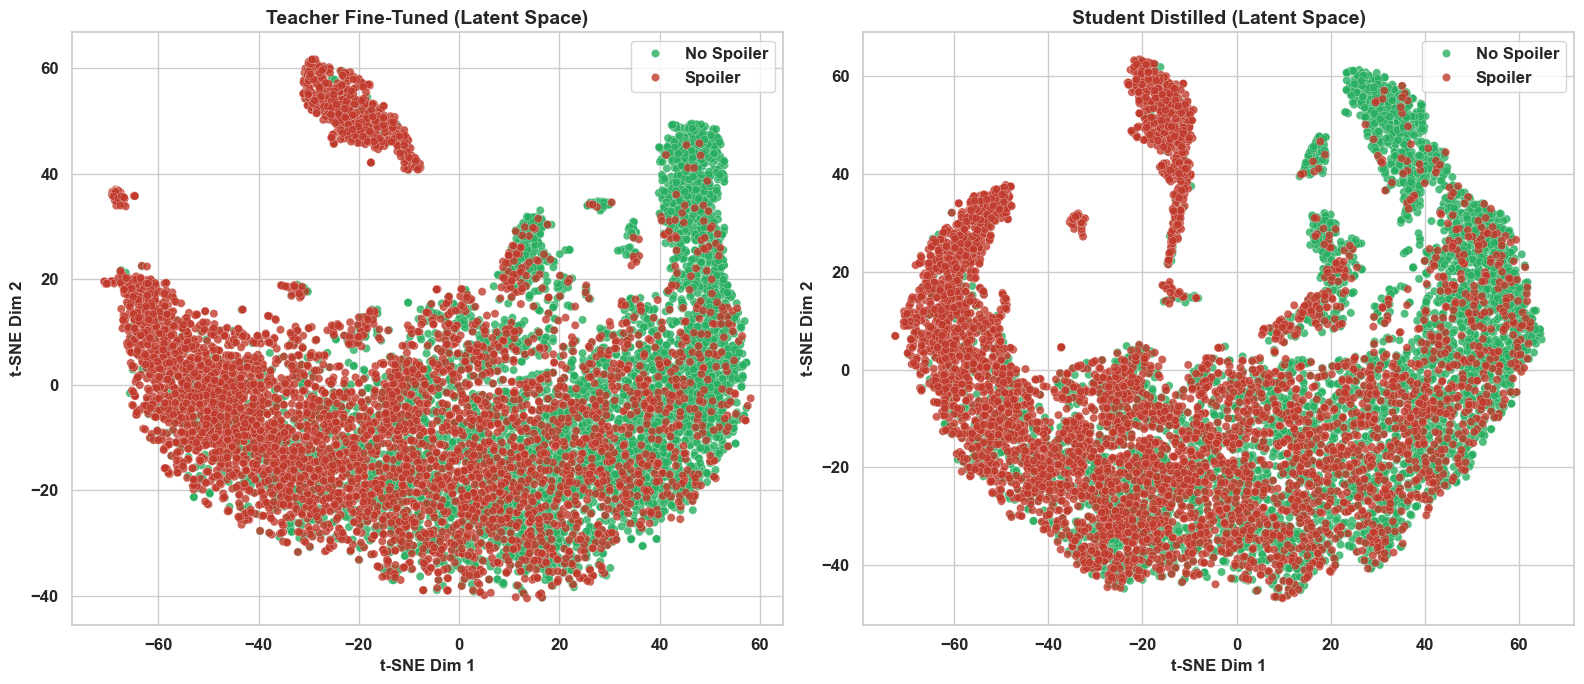

<Figure size 640x480 with 0 Axes>

In [14]:
# Creiamo i grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_data = [
    (tsne_teacher, "Teacher Fine-Tuned (Latent Space)"),
    (tsne_student, "Student Distilled (Latent Space)")
]

for ax, (tsne_coords, title) in zip(axes, plot_data):
    # Prepariamo il DataFrame per Seaborn
    df_plot = pd.DataFrame({
        't-SNE Dim 1': tsne_coords[:, 0],
        't-SNE Dim 2': tsne_coords[:, 1],
        'Label': [LABEL_MAP[l] for l in labels_teacher] # Le etichette sono identiche per entrambi
    })
    
    sns.scatterplot(
        data=df_plot,
        x='t-SNE Dim 1', y='t-SNE Dim 2',
        hue='Label',
        hue_order=["No Spoiler", "Spoiler"],
        palette=[PALETTE[0], PALETTE[1]],
        ax=ax,
        s=35,           # Dimensione dei punti
        alpha=0.8,      # Leggera trasparenza per vedere le sovrapposizioni
        linewidth=0.2,
        edgecolor='white'
    )
    
    # Applichiamo il font in grassetto ai titoli e alle label
    ax.set_title(title, fontweight='bold', fontsize=GLOBAL_FONT_SIZE + 2)
    ax.set_xlabel("t-SNE Dim 1", fontweight='bold', fontsize=GLOBAL_FONT_SIZE)
    ax.set_ylabel("t-SNE Dim 2", fontweight='bold', fontsize=GLOBAL_FONT_SIZE)
    
    # Assicuriamoci che i tick siano in grassetto
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')
        
    # Personalizzazione della legenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles, 
        labels=labels, 
        title="", 
        prop={'weight': 'bold', 'size': GLOBAL_FONT_SIZE},
        loc='best'
    )

plt.tight_layout()
plt.show()
plt.savefig('tsne.png')